## Progetto Machine Learning
1. [Importare i dati](#Scaricare-il-dataset-keaggle-Importare-librerie)
2. [Data Exploration](#Data-Exploration)
3. [Osservare il dataset](#Osservare il dataset)
4. [Training e Test](#Training e Test)
5. [Data Preprocessing](#Data-Processing)


#Scaricare il dataset keaggle Importare librerie
Caricamento dei dati tramite KaggleHub e configurazione iniziale dell'ambiente.

In [17]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("likithagedipudi/cupids-algorithm")

print("Path to dataset files:", path)
print("Archivos:", os.listdir(path))
archivio = os.listdir(path)
csv_path = os.path.join(path, archivio[0])

Using Colab cache for faster access to the 'cupids-algorithm' dataset.
Path to dataset files: /kaggle/input/cupids-algorithm
Archivos: ['cupid_algorithm_dataset.csv']


#Data Exploration

#Osservare il dataset
Analisi esplorativa (EDA): verifica della struttura del dataset e dei valori nulli (assenti).

In [18]:
df = pd.read_csv(csv_path)
df.head()


,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


###### Analisi delle informazioni del DataFrame per verificare tipi di dati e assenza di valori nulli.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_love_language                

###### Statistiche descrittive per analizzare i range e la distribuzione delle feature.

In [20]:
df.describe()


,pair_id,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,...,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,36.558140,2.951980,0.496463,0.499959,0.500131,0.501397,0.498643,0.499697,0.500012,...,0.499897,0.499177,0.500100,0.500063,0.500779,0.500324,0.500310,63.122273,0.428810,68.906250
std,28867.657797,10.951788,1.117733,0.174898,0.223607,0.224783,0.223860,0.223444,0.224779,0.226265,...,0.223567,0.223989,0.223253,0.223312,0.224214,0.226398,0.225954,10.705780,0.494909,21.334574
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.500000,0.000000,0.000000
25%,25000.750000,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.320000,0.330000,0.330000,...,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,55.900000,0.000000,54.000000
50%,50000.500000,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,63.000000,0.000000,69.000000
75%,75000.250000,46.000000,4.000000,0.620000,0.670000,0.670000,0.680000,0.670000,0.670000,0.670000,...,0.670000,0.670000,0.670000,0.670000,0.680000,0.680000,0.670000,70.300000,1.000000,83.000000
max,100000.000000,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,120.000000


Insights:
Etá: da 18 a 55 anni
Studi: numerica da 1, scuola media a 5 Dottorato
Personalitá: da 0 a 1

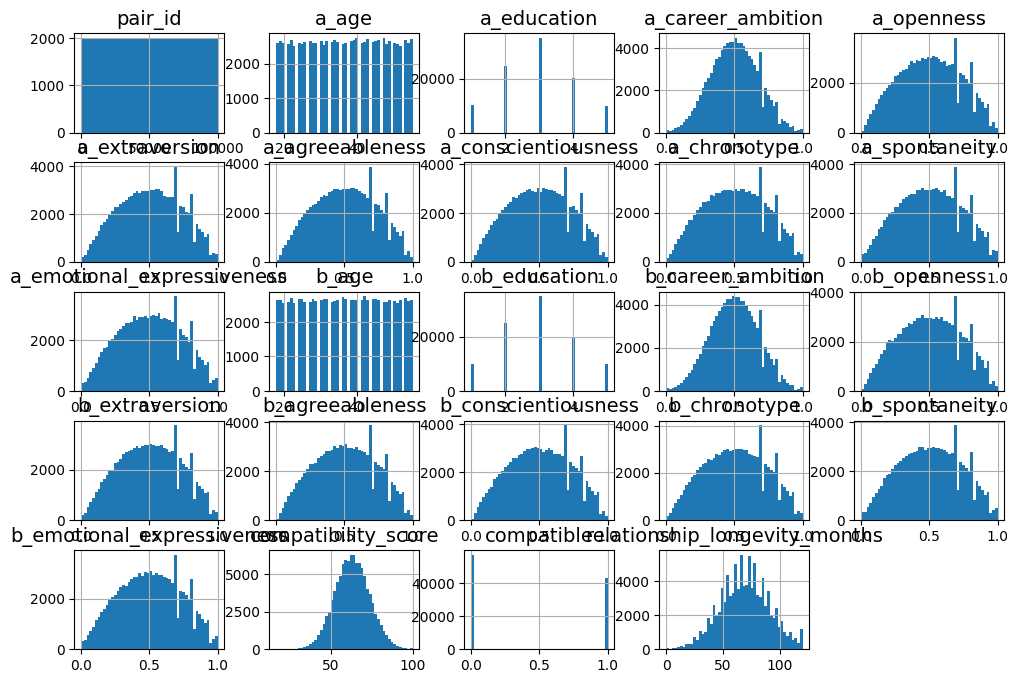

In [21]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.hist(bins=50, figsize=(12, 8))

plt.show()

Analisi del bilanciamento della classe target (compatible).

compatible
0    57119
1    42881
Name: count, dtype: int64


<Axes: >

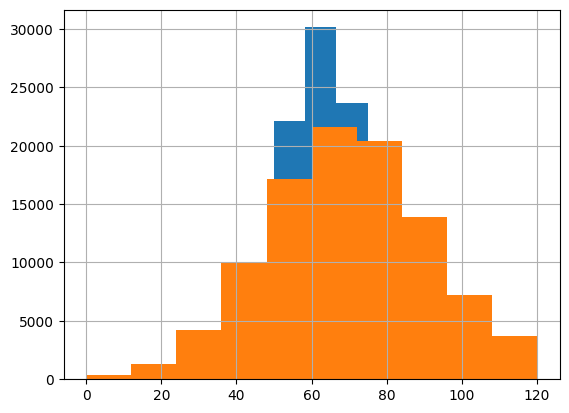

In [22]:
print(df["compatible"].value_counts())
df["compatibility_score"].hist()
df["relationship_longevity_months"].hist()

Aprox 43% compatibili e 57% no compatibili.

#Training e Test
##### Suddivisione in Training e Test set: rimozione delle variabili target per evitare il data leakage.

In [23]:
# Cancellare le colonne che vorremo predire o classificare e anche pair_id perche cosí ha suggerito la IA per evitare il leakage
X = df.drop(["pair_id", "compatible", "compatibility_score", "relationship_longevity_months"], axis=1)

# Definizione dei target
y_classificazione = df["compatible"]
y_regressione_1 = df["compatibility_score"]
y_regressione_2 = df["relationship_longevity_months"]

# Esecuzione della fase di classificazione binaria
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_classificazione, test_size=0.2, random_state=42)

X_train.info()
y_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   a_age                       80000 non-null  int64  
 1   a_education                 80000 non-null  int64  
 2   a_location                  80000 non-null  object 
 3   a_career_field              80000 non-null  object 
 4   a_career_ambition           80000 non-null  float64
 5   a_openness                  80000 non-null  float64
 6   a_extraversion              80000 non-null  float64
 7   a_agreeableness             80000 non-null  float64
 8   a_conscientiousness         80000 non-null  float64
 9   a_chronotype                80000 non-null  float64
 10  a_spontaneity               80000 non-null  float64
 11  a_love_language             80000 non-null  object 
 12  a_emotional_expressiveness  80000 non-null  float64
 13  b_age                       8000

In [24]:
cupid_class = X_train.copy()

# Pipeline di processamento

Preprocessing dei dati: ColumnTransformer con StandardScaler e OneHotEncoder.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    "a_age", "a_education", "a_career_ambition",
    "a_openness", "a_extraversion", "a_agreeableness", "a_conscientiousness",
    "a_chronotype", "a_spontaneity", "a_emotional_expressiveness",
    "b_age", "b_education", "b_career_ambition",
    "b_openness", "b_extraversion", "b_agreeableness", "b_conscientiousness",
    "b_chronotype", "b_spontaneity", "b_emotional_expressiveness"
]

cat_features = [
    "a_location", "a_career_field", "a_love_language",
    "b_location", "b_career_field", "b_love_language"
]

preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])


In [26]:
cupid_class_prepared = preprocessing.fit_transform(cupid_class)

In [27]:
# extra code – shows that we can get a DataFrame out if we want
cupid_class_prepared_df = pd.DataFrame(
    cupid_class_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=cupid_class.index)
cupid_class_prepared_df.head(2)

,num__a_age,num__a_education,num__a_career_ambition,num__a_openness,num__a_extraversion,num__a_agreeableness,num__a_conscientiousness,num__a_chronotype,num__a_spontaneity,num__a_emotional_expressiveness,...,cat__b_career_field_Healthcare,cat__b_career_field_Law,cat__b_career_field_Marketing,cat__b_career_field_Science,cat__b_career_field_Tech,cat__b_love_language_Acts of Service,cat__b_love_language_Physical Touch,cat__b_love_language_Quality Time,cat__b_love_language_Receiving Gifts,cat__b_love_language_Words of Affirmation
75220,-1.600841,0.938506,-0.550240,-0.044492,1.069760,-0.092568,0.587869,-1.287262,-1.414173,0.090288,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48955,-1.600841,-0.850978,0.649312,1.431750,-1.068394,0.621715,-0.084073,0.669557,-0.310128,-1.898037,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Pipeline di classificazione

Creare e allenare il classificatore

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# 'prep' per applicare ColumnTransformer che abbiamo fatto prima
# 'classifier' é il nostro Random Forest

clf_pipeline = Pipeline([
    ("prep", preprocessing),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# ALLENAMENTO
# .fit()
clf_pipeline.fit(X_train, y_train)

print("Modello allenato!")

Modello allenato!


Cross validation

In [29]:
from sklearn.model_selection import cross_val_score

# Prova del modello
scores_rf = cross_val_score(clf_pipeline, X_train, y_train, cv=3, scoring="f1")
print(f"F1-Score promedio Random Forest: {scores_rf.mean():.4f}")


F1-Score promedio Random Forest: 0.4305


Costruiamo la matrice di confusione, che è più informativa dell'accuratezza.

Per prima cosa dobbiamo ricavare le predizioni, non solo i valori di accuratezza.


In [30]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Facciamo le predizione con cross validation
y_train_pred = cross_val_predict(clf_pipeline, X_train, y_train, cv=3)

# Matrice di confusione
cm = confusion_matrix(y_train, y_train_pred)
print("Matrice di confusione:")
print(cm)

# Valutazione delle performance: Matrice di Confusione e F1-Score.
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print(f"\nPrecision: {precision:.4f} (¿Qué tan fiable es cuando dice que son compatibles?)")
print(f"Recall:    {recall:.4f} (¿Cuántas parejas compatibles reales detectó?)")
print(f"F1 Score:  {f1:.4f} (Balance entre Precision y Recall)")

Matrice di confusione:
[[39229  6455]
 [23133 11183]]

Precision: 0.6340 (¿Qué tan fiable es cuando dice que son compatibles?)
Recall:    0.3259 (¿Cuántas parejas compatibles reales detectó?)
F1 Score:  0.4305 (Balance entre Precision y Recall)
